<a href="https://colab.research.google.com/github/ruhmmachaudhary-rgb/Ai-academic-burnout-predictor/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IMPORTS + SETUP

we import all necessary Python libraries required for data processing, model building, evaluation, and visualization.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib

## DATASET 1 (SAME TRAINING)

We load the first dataset related to academic stress. This dataset contains student academic and psychological indicators.

In [2]:
df1 = pd.read_csv("/content/academic Stress level - maintainance 1.csv")

df1.columns = df1.columns.str.strip()

df1.drop(columns=["Timestamp"], inplace=True)
df1.fillna(df1.mode().iloc[0], inplace=True)

for col in df1.columns:
    if df1[col].dtype == "object":
        df1[col] = LabelEncoder().fit_transform(df1[col].astype(str))

target1 = "Rate your academic stress index"

y1 = df1[target1]
X1 = df1.drop(columns=[target1])

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

model1 = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
model1.fit(X1_train, y1_train)

y1_pred = model1.predict(X1_test)

print("Dataset 1 Accuracy:", accuracy_score(y1_test, y1_pred))

Dataset 1 Accuracy: 0.25


## DATASET 2 (SAME TRAINING)

We train a Random Forest model to predict stress levels based on student featu
We clean the dataset by handling missing values and converting categorical variables into numeric format so the model can understand them.

In [3]:
df2 = pd.read_csv("/content/student_mental_health_burnout.csv")

df2.drop(columns=["student_id"], inplace=True)
df2.fillna(df2.mode().iloc[0], inplace=True)

for col in df2.columns:
    if df2[col].dtype == "object":
        df2[col] = LabelEncoder().fit_transform(df2[col].astype(str))

y2 = df2["burnout_level"]
X2 = df2.drop(columns=["burnout_level"])

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

model2 = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42)
model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)

print("Dataset 2 Accuracy:", accuracy_score(y2_test, y2_pred))

Dataset 2 Accuracy: 0.3341


Confusion Matrix Function

Confusion matrix is used to evaluate classification performance by comparing predicted vs actual values.

In [4]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Dataset 1 Graphs

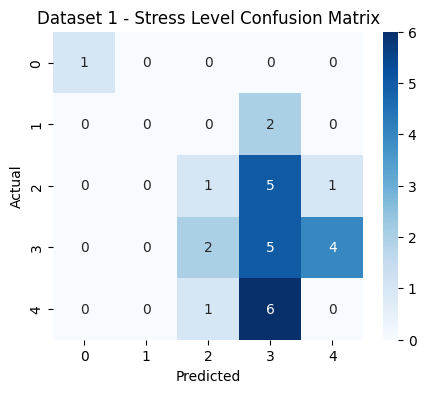


Dataset 1 Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           2       0.00      0.00      0.00         2
           3       0.25      0.14      0.18         7
           4       0.28      0.45      0.34        11
           5       0.00      0.00      0.00         7

    accuracy                           0.25        28
   macro avg       0.31      0.32      0.31        28
weighted avg       0.21      0.25      0.22        28



In [5]:
plot_cm(y1_test, y1_pred, "Dataset 1 - Stress Level Confusion Matrix")

print("\nDataset 1 Report:\n")
print(classification_report(y1_test, y1_pred))

Dataset 2 Graphs

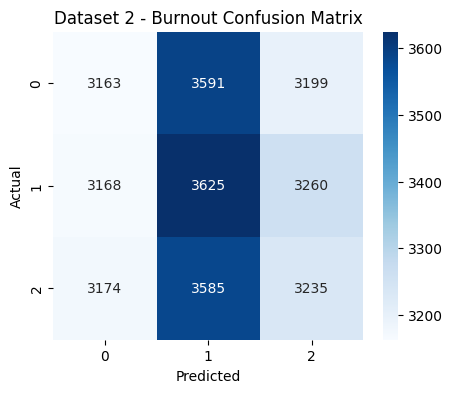


Dataset 2 Report:

              precision    recall  f1-score   support

           0       0.33      0.32      0.33      9953
           1       0.34      0.36      0.35     10053
           2       0.33      0.32      0.33      9994

    accuracy                           0.33     30000
   macro avg       0.33      0.33      0.33     30000
weighted avg       0.33      0.33      0.33     30000



In [6]:
plot_cm(y2_test, y2_pred, "Dataset 2 - Burnout Confusion Matrix")

print("\nDataset 2 Report:\n")
print(classification_report(y2_test, y2_pred))

## faeture importance

Feature importance shows which input variables have the most impact on predictions.

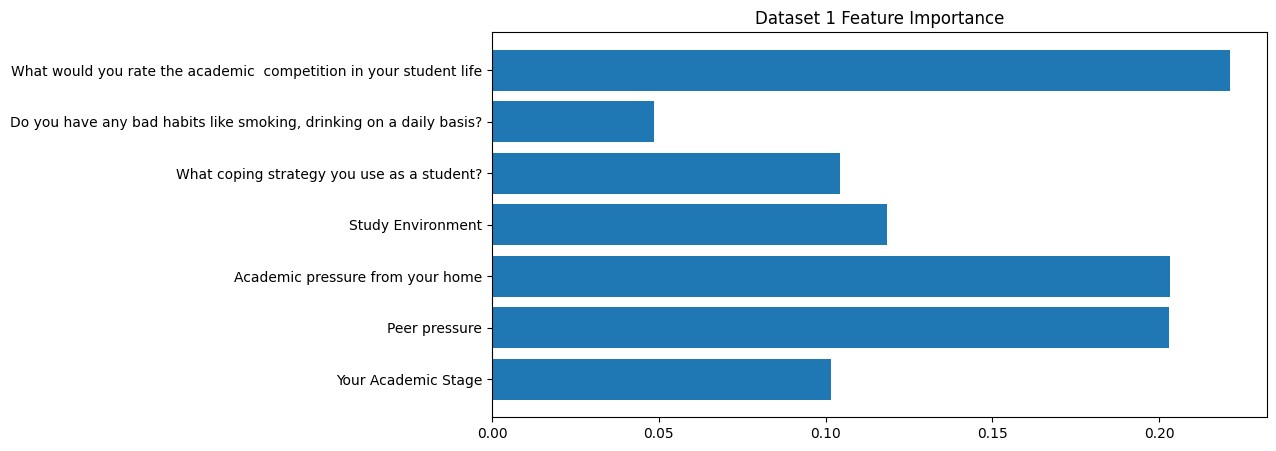

In [7]:
importances = model1.feature_importances_
features = X1.columns

plt.figure(figsize=(10,5))
plt.barh(features, importances)
plt.title("Dataset 1 Feature Importance")
plt.show()

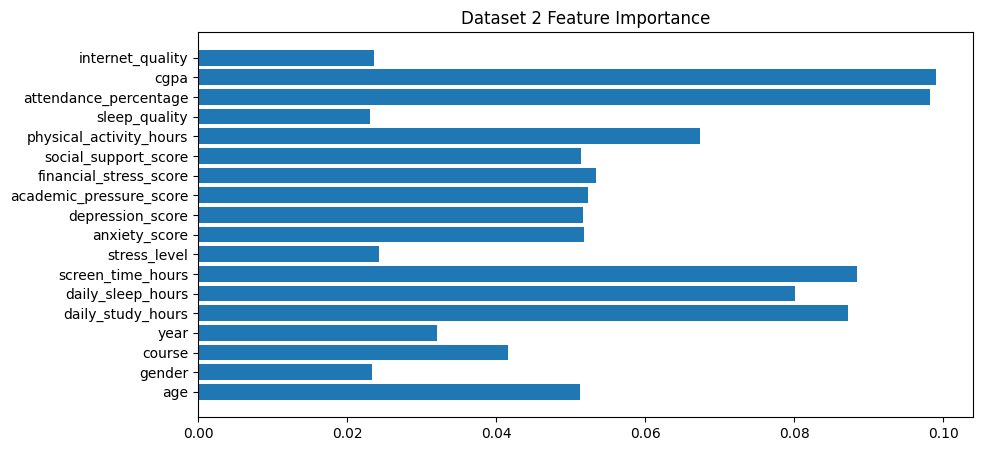

In [8]:
importances = model2.feature_importances_
features = X2.columns

plt.figure(figsize=(10,5))
plt.barh(features, importances)
plt.title("Dataset 2 Feature Importance")
plt.show()

We compare both models based on accuracy to evaluate which model performs better.

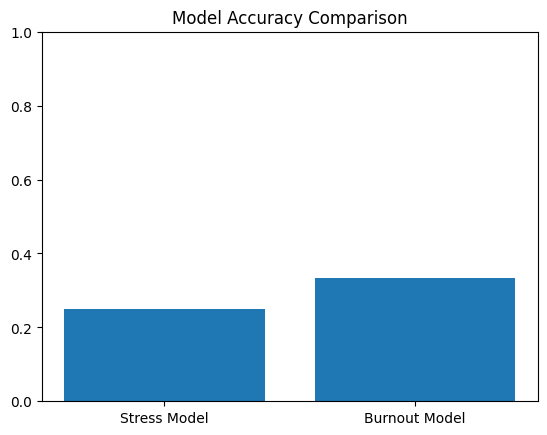

In [9]:
models = ["Stress Model", "Burnout Model"]
acc = [
    accuracy_score(y1_test, y1_pred),
    accuracy_score(y2_test, y2_pred)
]

plt.bar(models, acc)
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()

## SAVE MODELS

We save trained models so they can be used later in deployment (Streamlit app) without retraining.

In [10]:
joblib.dump(model1, "stress_model.pkl")
joblib.dump(model2, "burnout_model.pkl")
print("Models Saved Successfully ")


Models Saved Successfully 


In [11]:
from google.colab import files
files.download("burnout_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>